# 01. CRF NER — EDA silver

Проверка **weak BIO** для будущего CRF (обучение → [`02_crf_classifier.ipynb`](./02_crf_classifier.ipynb)).

## MVP context

| слой | статус |
|---|---|
| Brand clf (TF-IDF) | MVP |
| ATTR type clf (TF-IDF) | MVP |
| **CRF spans** | этот трек |

Старые [`06`](../06_weak_supervision_ner.ipynb) / [`08`](../08_train_ner_model.ipynb): без `models_path`, silver не сохраняли, F1 silver↔silver. Разбор: [`crf_ner_status.md`](./crf_ner_status.md).

## CRF ≠ TF-IDF

Фичи токена: `word.lower`, prefix/suffix, **shape**, digit/latin/cyrillic, соседи ±1/±2.  
Опечатки ловятся слабо (нет edit-distance). TF-IDF — у brand/attr clf.


## 0. Setup

In [1]:
%matplotlib inline
import sys, json, warnings
from pathlib import Path
from collections import Counter

ROOT = Path.cwd().resolve()
if ROOT.name in {"crf_ner_classifier", "notebooks"}:
    ROOT = ROOT.parents[1] if ROOT.name == "crf_ner_classifier" else ROOT.parent
sys.path.insert(0, str(ROOT))

import pandas as pd
import matplotlib.pyplot as plt

from src.data_utils import (
    ARTIFACTS_DIR, FIGURES_DIR, ensure_dirs, apply_plot_style,
    load_query_clicks, MVIDEO_RED, DARK_SLATE,
)
from src.ner.labeling import WeakLabeler, bio_to_entities, tokenize
from src.preprocessing.pipeline import basic_clean, _norm_key

warnings.filterwarnings("ignore", category=FutureWarning)
ensure_dirs()
apply_plot_style()

OUT = ROOT / "artifacts" / "ner"
OUT.mkdir(parents=True, exist_ok=True)
FIG = FIGURES_DIR / "ner"
FIG.mkdir(parents=True, exist_ok=True)
GOLD = ROOT / "data" / "gold" / "bio_liza.jsonl"
SEED, SAMPLE_N, MAX_QUERIES = 42, 60_000, 5_000
print("OUT", OUT)


d:\Projects-26-06-2026\mvideo-ner-search\.venv\Lib\site-packages\pymorphy2\analyzer.py:114: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


OUT D:\Projects-26-06-2026\mvideo-ner-search\artifacts\ner


## 1. Как классифицирует CRF

In [2]:
from src.ner.features import sent2features

demo = [("ноутбук", "B-CATEGORY"), ("asus", "B-BRAND"), ("tuf", "B-MODEL"), ("16", "B-ATTR"), ("гб", "I-ATTR")]
feats = sent2features(demo)
print("token features for 'asus':")
for k, v in sorted(feats[1].items()):
    print(f"  {k}: {v}")
print("\n→ CRF учит P(tag_i | feats, tag_{i-1}), не TF-IDF по запросу.")


token features for 'asus':
  +1:word.istitle: False
  +1:word.isupper: False
  +1:word.lower: tuf
  +1:word.shape: x
  +2:word.lower: 16
  -1:word.istitle: False
  -1:word.isupper: False
  -1:word.lower: ноутбук
  -1:word.shape: x
  bias: 1.0
  word.has_cyrillic: False
  word.has_digit: False
  word.has_latin: True
  word.isalpha: True
  word.isdigit: False
  word.istitle: False
  word.isupper: False
  word.len: 4
  word.lower: asus
  word.shape: x
  word[-2:]: us
  word[-3:]: sus
  word[:2]: as
  word[:3]: asu

→ CRF учит P(tag_i | feats, tag_{i-1}), не TF-IDF по запросу.


## 2. WeakLabeler: с MODEL vs legacy (06/08)

Подключаем `artifacts/model_phrases.txt` — иначе MODEL почти нет.


In [3]:
labeler_full = WeakLabeler.from_files(
    ARTIFACTS_DIR / "brands.txt",
    ARTIFACTS_DIR / "categories.txt",
    models_path=ARTIFACTS_DIR / "model_phrases.txt",
)
labeler_legacy = WeakLabeler.from_files(
    ARTIFACTS_DIR / "brands.txt",
    ARTIFACTS_DIR / "categories.txt",
)
print(f"brands={len(labeler_full.brands)} cats={len(labeler_full.categories)} models={len(labeler_full.models)}")

for q in ["asus tuf gaming a15 16 гб", "iphone 15 pro max", "ноутбук asus 16гб"]:
    full = " ".join(f"{a}/{b}" for a, b in labeler_full.label_query(q))
    leg = " ".join(f"{a}/{b}" for a, b in labeler_legacy.label_query(q))
    print(f"\nQ: {q}\n  full:   {full}\n  legacy: {leg}")


brands=1609 cats=1431 models=6130

Q: asus tuf gaming a15 16 гб
  full:   asus/B-BRAND tuf/B-MODEL gaming/I-MODEL a15/I-MODEL 16/B-ATTR гб/I-ATTR
  legacy: asus/B-BRAND tuf/O gaming/O a15/O 16/B-ATTR гб/I-ATTR

Q: iphone 15 pro max
  full:   iphone/B-BRAND 15/B-MODEL pro/I-MODEL max/B-BRAND
  legacy: iphone/B-BRAND 15/O pro/O max/B-BRAND

Q: ноутбук asus 16гб
  full:   ноутбук/B-CATEGORY asus/B-BRAND 16/B-ATTR гб/I-ATTR
  legacy: ноутбук/B-CATEGORY asus/B-BRAND 16/B-ATTR гб/I-ATTR


## 3. Silver slice из кликов

In [4]:
def entity_counts(tags):
    c = Counter()
    for t in tags:
        if t.startswith("B-"):
            c[t[2:]] += 1
    return c

def sent_to_row(query, tags_pairs, source):
    tokens = [t for t, _ in tags_pairs]
    tags = [g for _, g in tags_pairs]
    ents = bio_to_entities(tags_pairs, query=query)
    ec = entity_counts(tags)
    return {
        "query": query, "n_tokens": len(tokens), "tokens": tokens, "tags": tags,
        "n_entities": sum(1 for t in tags if t.startswith("B-")),
        "n_BRAND": ec["BRAND"], "n_CATEGORY": ec["CATEGORY"],
        "n_MODEL": ec["MODEL"], "n_ATTR": ec["ATTR"],
        "has_entity": any(t != "O" for t in tags),
        "bio_str": " ".join(f"{a}/{b}" for a, b in tags_pairs),
        "entities_json": json.dumps(
            [{"text": e["text"], "label": e["label"]} for e in ents], ensure_ascii=False
        ),
        "source": source,
    }

clicks = load_query_clicks()
if len(clicks) > SAMPLE_N:
    clicks = clicks.sample(n=SAMPLE_N, random_state=SEED)
qcol = "query_text" if "query_text" in clicks.columns else "query"
queries = (
    clicks[qcol].astype(str)
    .map(lambda x: basic_clean(x, lowercase=False))
    .map(_norm_key).drop_duplicates()
)
queries = [q for q in queries.tolist() if len(q) >= 2][:MAX_QUERIES]
print("queries", len(queries))

rows = []
for q in queries:
    sent = labeler_full.label_query(q)
    if sent:
        rows.append(sent_to_row(q, sent, "weak_with_model"))
silver = pd.DataFrame(rows)
silver_ent = silver[silver["has_entity"]]
print(f"silver={len(silver):,} with_entity={len(silver_ent):,} ({len(silver_ent)/max(1,len(silver)):.1%})")
display(silver_ent[["query", "n_tokens", "n_BRAND", "n_CATEGORY", "n_MODEL", "n_ATTR", "bio_str"]].head(12))


queries 5000
silver=5,000 with_entity=4,344 (86.9%)


,query,n_tokens,n_BRAND,n_CATEGORY,n_MODEL,n_ATTR,bio_str
0,samsung,1,1,0,0,0,samsung/B-BRAND
1,накопительные водонагреватели,2,0,1,0,0,накопительные/B-CATEGORY водонагреватели/I-CAT...
2,мышь,1,0,1,0,0,мышь/B-CATEGORY
3,пылесос,1,0,1,0,0,пылесос/B-CATEGORY
4,геймпад xbox,2,1,1,0,0,геймпад/B-CATEGORY xbox/B-BRAND
5,samsung s25 ultra,3,1,0,1,0,samsung/B-BRAND s25/B-MODEL ultra/I-MODEL
6,nintendo switch 2,3,1,0,1,0,nintendo/B-BRAND switch/B-MODEL 2/I-MODEL
7,тихий пылесос,2,0,1,0,0,тихий/O пылесос/B-CATEGORY
8,фен для волос,3,0,1,0,0,фен/B-CATEGORY для/I-CATEGORY волос/I-CATEGORY
9,клавиатура,1,0,1,0,0,клавиатура/B-CATEGORY


## 4. Распределения

,entity,B_count
0,BRAND,2446
1,CATEGORY,3560
2,MODEL,663
3,ATTR,782


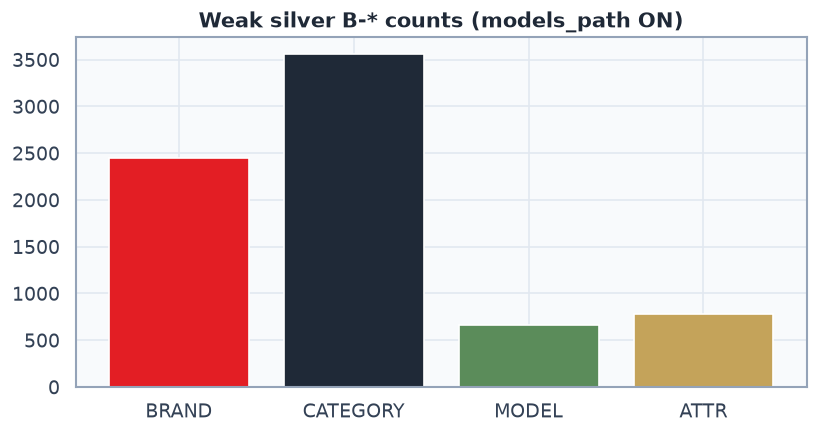

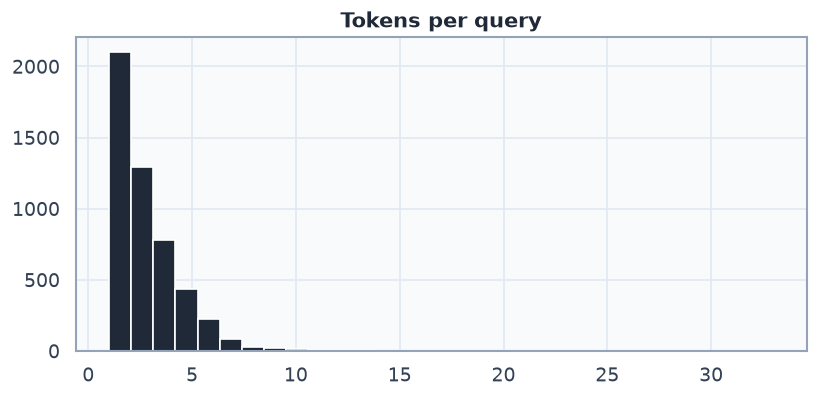

mean tokens=3.1 p95=6


In [5]:
type_counts = Counter()
for _, r in silver_ent.iterrows():
    type_counts["BRAND"] += int(r["n_BRAND"])
    type_counts["CATEGORY"] += int(r["n_CATEGORY"])
    type_counts["MODEL"] += int(r["n_MODEL"])
    type_counts["ATTR"] += int(r["n_ATTR"])
labs = ["BRAND", "CATEGORY", "MODEL", "ATTR"]
display(pd.DataFrame([{"entity": l, "B_count": type_counts[l]} for l in labs]))

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.bar(labs, [type_counts[l] for l in labs], color=[MVIDEO_RED, DARK_SLATE, "#5B8C5A", "#C4A35A"])
ax.set_title("Weak silver B-* counts (models_path ON)")
fig.tight_layout()
fig.savefig(FIG / "01_entity_counts.png", dpi=120, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(silver["n_tokens"], bins=30, color=DARK_SLATE, edgecolor="white")
ax.set_title("Tokens per query")
fig.tight_layout()
fig.savefig(FIG / "01_token_len.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"mean tokens={silver.n_tokens.mean():.1f} p95={silver.n_tokens.quantile(0.95):.0f}")


## 5. Gold parity

`bio_liza.jsonl`: теги vs `split` vs prod `tokenize()`. CRF **не** использует `subtypes`.


In [6]:
gold_rows = [json.loads(l) for l in GOLD.read_text(encoding="utf-8").splitlines() if l.strip()]
recs = []
for r in gold_rows:
    q = r["query"]
    tags = r["tags"]
    toks_split = q.split()
    toks_tok = [t for t, _, _ in tokenize(q)]
    recs.append({
        "query": q,
        "n_tags": len(tags),
        "split_align": len(toks_split) == len(tags),
        "tokenize_align": len(toks_tok) == len(tags),
        "tags": tags,
        "subtypes": r.get("subtypes") or {},
        "tokens_tokenize": toks_tok,
    })
gdf = pd.DataFrame(recs)
print(f"gold={len(gdf)} split_align={gdf.split_align.sum()} tokenize_align={gdf.tokenize_align.sum()}")
gc = Counter()
for tags in gdf["tags"]:
    gc.update(entity_counts(tags))
display(pd.DataFrame([{"entity": k, "B_count": v} for k, v in gc.most_common()]))
print("subtypes present:", sum(1 for s in gdf["subtypes"] if s), "/", len(gdf), "(ignored by CRF)")


gold=200 split_align=200 tokenize_align=181


,entity,B_count
0,CATEGORY,153
1,BRAND,106
2,ATTR,91
3,MODEL,74


subtypes present: 70 / 200 (ignored by CRF)


## 6. Weak vs gold (span micro-F1)

In [7]:
def bio_span_set(tokens, tags):
    out = set()
    i = 0
    while i < len(tags):
        if tags[i].startswith("B-"):
            lab = tags[i][2:]
            j = i + 1
            while j < len(tags) and tags[j] == f"I-{lab}":
                j += 1
            out.add((lab, " ".join(tokens[i:j]).lower()))
            i = j
        else:
            i += 1
    return out

tp = fp = fn = 0
conf = Counter()
for _, gr in gdf.iterrows():
    q = gr["query"]
    pred = labeler_full.label_query(q)
    pred_toks = [t for t, _ in pred]
    pred_tags = [t for _, t in pred]
    if gr["tokenize_align"]:
        gold_set = bio_span_set(gr["tokens_tokenize"], gr["tags"])
    else:
        gold_set = bio_span_set(q.split(), gr["tags"])
    pred_set = bio_span_set(pred_toks, pred_tags)
    tp += len(gold_set & pred_set)
    fp += len(pred_set - gold_set)
    fn += len(gold_set - pred_set)
    for lab, span in gold_set:
        hit = [p for p in pred_set if p[1] == span]
        conf[(lab, hit[0][0] if hit else "MISS")] += 1

prec = tp / max(1, tp + fp)
rec = tp / max(1, tp + fn)
f1 = 2 * prec * rec / max(1e-9, prec + rec)
print(f"span micro: P={prec:.3f} R={rec:.3f} F1={f1:.3f}  tp={tp} fp={fp} fn={fn}")
display(pd.DataFrame(
    [{"gold": g, "teacher": t, "n": n} for (g, t), n in conf.most_common(15)]
))


span micro: P=0.669 R=0.491 F1=0.566  tp=208 fp=103 fn=216


,gold,teacher,n
0,CATEGORY,CATEGORY,89
1,BRAND,BRAND,86
2,MODEL,MISS,62
3,CATEGORY,MISS,61
4,ATTR,MISS,60
5,ATTR,ATTR,22
6,BRAND,MISS,19
7,MODEL,MODEL,11
8,ATTR,CATEGORY,8
9,CATEGORY,BRAND,2


## 7. Save artifacts

In [8]:
silver.to_parquet(OUT / "silver_bio_slice.parquet", index=False)
silver_ent.head(200).to_parquet(OUT / "silver_bio_preview.parquet", index=False)
meta = {
    "n_silver": len(silver),
    "n_with_entity": len(silver_ent),
    "entity_counts": dict(type_counts),
    "gold_n": len(gdf),
    "gold_tokenize_align": int(gdf.tokenize_align.sum()),
    "weak_gold_f1": round(f1, 4),
    "models_path": True,
}
(OUT / "eda_meta.json").write_text(json.dumps(meta, ensure_ascii=False, indent=2), encoding="utf-8")
pd.DataFrame([
    {"metric": "queries", "value": len(queries)},
    {"metric": "silver_with_entity", "value": len(silver_ent)},
    {"metric": "weak_gold_f1", "value": round(f1, 4)},
]).to_csv(OUT / "silver_overview.csv", index=False)
print("saved", OUT)
print("See also 01_crf_eda_report.md (from _run_01.py) and crf_ner_status.md")


saved D:\Projects-26-06-2026\mvideo-ner-search\artifacts\ner
See also 01_crf_eda_report.md (from _run_01.py) and crf_ner_status.md


## Verdict

1. Для MVP CRF silver ок **только с `models_path`**.
2. 06/08 / старый `ner_crf.pkl` без MODEL — **не** согласованы с gold.
3. Обучение → `02_crf_classifier.ipynb`; метрика №1 — **gold F1**, не silver↔silver.

Headless: `python notebooks/crf_ner_classifier/_run_01.py`
